In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pycountry

In [30]:
df_salary = pd.read_csv("../data/raw/salary_data/salaries.csv")


In [31]:
df_salary.head()


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [32]:
df_salary.info()

<class 'pandas.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   work_year           151445 non-null  int64
 1   experience_level    151445 non-null  str  
 2   employment_type     151445 non-null  str  
 3   job_title           151445 non-null  str  
 4   salary              151445 non-null  int64
 5   salary_currency     151445 non-null  str  
 6   salary_in_usd       151445 non-null  int64
 7   employee_residence  151445 non-null  str  
 8   remote_ratio        151445 non-null  int64
 9   company_location    151445 non-null  str  
 10  company_size        151445 non-null  str  
dtypes: int64(4), str(7)
memory usage: 12.7 MB


In [33]:
df_salary.isnull().sum()

work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [34]:
df_salary.duplicated().sum()

np.int64(79532)

In [35]:
df_salary = df_salary.drop_duplicates()

In [36]:
df_salary.columns = (
    df_salary.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)

In [37]:
df_salary["experience_level"].unique()

<StringArray>
['EX', 'SE', 'MI', 'EN']
Length: 4, dtype: str

In [38]:
df_salary["remote_ratio"].unique()

array([  0, 100,  50])

In [39]:
df_salary["employment_type"].unique()

<StringArray>
['FT', 'PT', 'CT', 'FL']
Length: 4, dtype: str

In [40]:
df_salary["experience_level"] = df_salary["experience_level"].replace({
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive Level"
})

In [41]:
df_salary["employment_type"] = df_salary["employment_type"].replace({
    "FT": "Full-Time",
    "PT": "Part-Time",
    "CT": "Contract",
    "FL": "Freelance"
})


In [42]:
df_salary["remote_ratio"] = df_salary["remote_ratio"].replace({
    0: "On-site",
    50: "Hybrid",
    100: "Remote"
})

In [43]:
def country_name(code):
    try:
        return pycountry.countries.get(alpha_2=code).name
    except:
        return code


df_salary["employee_residence"] = df_salary["employee_residence"].apply(country_name)

df_salary["company_location"] = df_salary["company_location"].apply(country_name)

In [44]:
df_salary = df_salary.drop(columns=["salary", "salary_currency"])


In [45]:
df_salary.head()

,work_year,experience_level,employment_type,job_title,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,Executive Level,Full-Time,Head of Data,348516,United States,On-site,United States,M
1,2025,Executive Level,Full-Time,Head of Data,232344,United States,On-site,United States,M
2,2025,Senior Level,Full-Time,Data Scientist,145400,United States,On-site,United States,M
3,2025,Senior Level,Full-Time,Data Scientist,81600,United States,On-site,United States,M
4,2025,Mid Level,Full-Time,Engineer,160000,United States,Remote,United States,M


In [46]:
df_salary["job_title"].value_counts().head(10)

job_title
Data Scientist               7160
Data Engineer                7071
Data Analyst                 6405
Software Engineer            4921
Engineer                     4375
Manager                      3612
Machine Learning Engineer    3462
Analyst                      2783
Research Scientist           1381
Analytics Engineer           1341
Name: count, dtype: int64

 AVERAGE SALARY BY EXPERIENCE

In [47]:
df_salary.groupby("employment_type")["salary_in_usd"].mean()

employment_type
Contract     104232.660574
Freelance     50651.562500
Full-Time    151785.783736
Part-Time     80330.193732
Name: salary_in_usd, dtype: float64

In [48]:
df_salary["remote_ratio"].value_counts()

remote_ratio
On-site    54081
Remote     17505
Hybrid       327
Name: count, dtype: int64

In [49]:
df_salary.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False).head(10)


job_title
Research Team Lead                       450000.0
Analytics Engineering Manager            399880.0
Data Science Tech Lead                   375000.0
Head of Machine Learning                 300620.6
Applied AI ML Lead                       292500.0
IT Enterprise Data Architect             284090.0
Head of Applied AI                       278500.0
Director of Machine Learning             265200.0
AIRS Solutions Specialist                263250.0
Machine Learning Performance Engineer    262500.0
Name: salary_in_usd, dtype: float64

In [50]:
df_salary["company_location"].value_counts().head(10)

company_location
United States     60147
Canada             4571
United Kingdom     2835
Australia           511
Germany             400
Netherlands         398
Lithuania           312
France              302
Spain               223
India               207
Name: count, dtype: int64

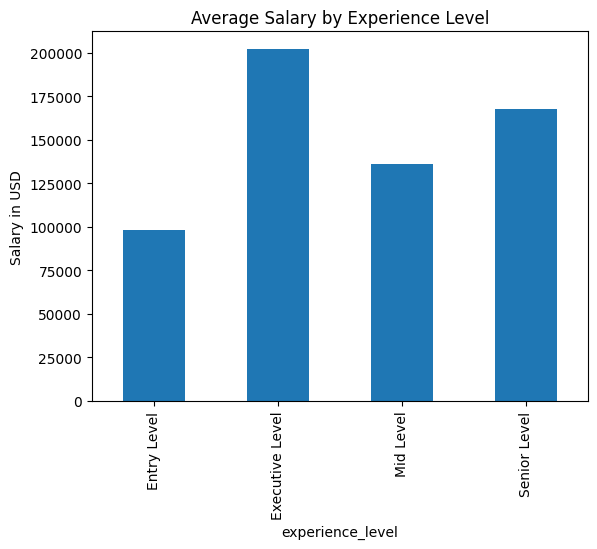

In [51]:
df_salary.groupby("experience_level")["salary_in_usd"].mean().plot(kind="bar")

plt.title("Average Salary by Experience Level")
plt.ylabel("Salary in USD")
plt.show()

 SAVE CLEANED DATASET

In [52]:
df_salary.to_csv(
    r"C:\Projects\JobPulse\data\cleaned\cleaned_salaries.csv",
    index=False
)